# Credit Card Fraud Detection using Machine Learning

## Introduction

Credit card fraud causes significant financial losses every year, and fraudulent transactions
make up only a tiny fraction of all transactions — making detection a challenging **imbalanced
classification problem**.

This project builds a fraud detection system using the popular **Credit Card Fraud Detection
dataset** (284,807 transactions, of which only 492 are fraudulent). The workflow covers:

- Exploratory Data Analysis (EDA) and visualization of class imbalance
- Handling imbalance through **undersampling**
- Feature scaling
- Training and comparing **four classification models**: Logistic Regression, Decision Tree,
  Random Forest, and K-Nearest Neighbors (KNN)
- Evaluating models using Accuracy, Confusion Matrix, Classification Report, ROC-AUC, and
  Precision-Recall curves
- Identifying the best-performing model for fraud detection

---

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
classification_report, roc_curve, roc_auc_score, precision_recall_curve)

In [2]:
df = pd.read_csv('creditcard.csv')

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.shape

(284807, 31)

#### 0 = Legit Transaction (Normal)
#### 1 = Fraud Transaction

In [7]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

This is clearly an **imbalanced dataset** — fraud transactions are a tiny fraction of total transactions.

### Visualizing the Class Imbalance

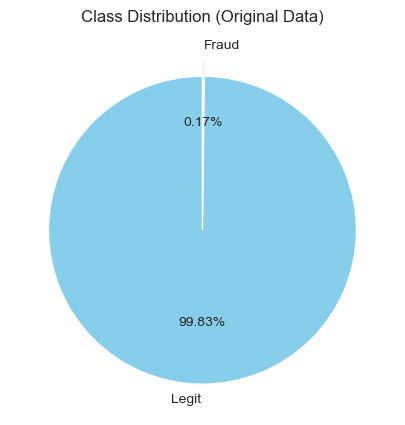

In [8]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(6,5))
plt.pie(class_counts, labels=['Legit', 'Fraud'], autopct='%1.2f%%',
        colors=['skyblue', 'salmon'], explode=(0.05, 0.05), startangle=90)
plt.title('Class Distribution (Original Data)')
plt.show()

### Class Count (Original Data)

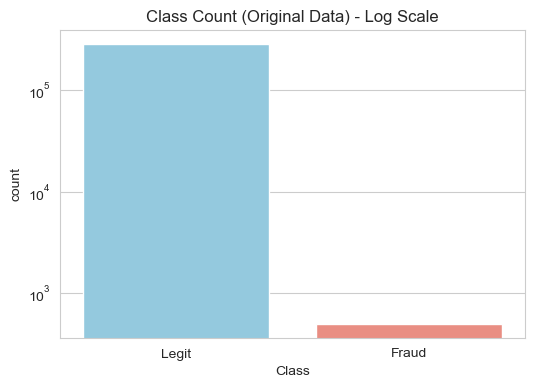

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['skyblue', 'salmon'])
plt.title('Class Count (Original Data) - Log Scale')
plt.yscale('log')  
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.show()

### Transaction Amount Analysis

In [10]:
normal = df[df.Class == 0]
fraud = df[df.Class == 1]

print("Normal Transactions:", normal.shape)
print("Fraud Transactions  :", fraud.shape)

Normal Transactions: (284315, 31)
Fraud Transactions  : (492, 31)


In [11]:
print("Normal Amount Stats:")
print(normal.Amount.describe())
print('-'*30)
print("\nFraud Amount Stats:")
print(fraud.Amount.describe())

Normal Amount Stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64
------------------------------

Fraud Amount Stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


### Amount Distribution legit and Fraud

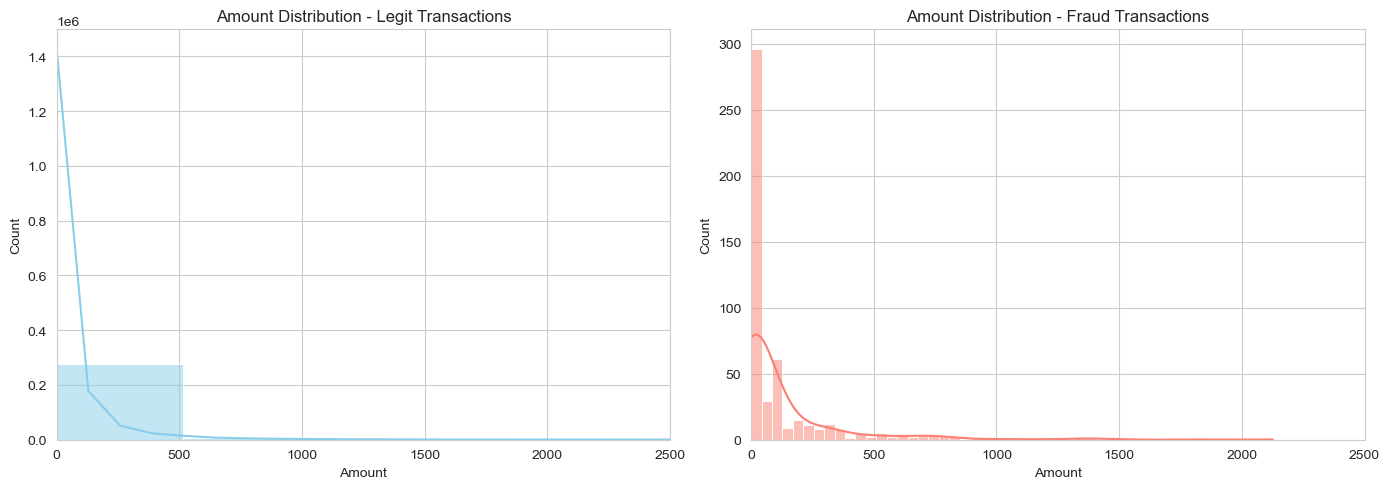

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(normal['Amount'], bins=50, color='skyblue', ax=axes[0], kde=True)
axes[0].set_title('Amount Distribution - Legit Transactions')
axes[0].set_xlim(0, 2500)

sns.histplot(fraud['Amount'], bins=50, color='salmon', ax=axes[1], kde=True)
axes[1].set_title('Amount Distribution - Fraud Transactions')
axes[1].set_xlim(0, 2500)

plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
df.groupby('Class').mean(numeric_only=True)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,94838.202258,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000644,-0.001235,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


### Correlation Heatmap

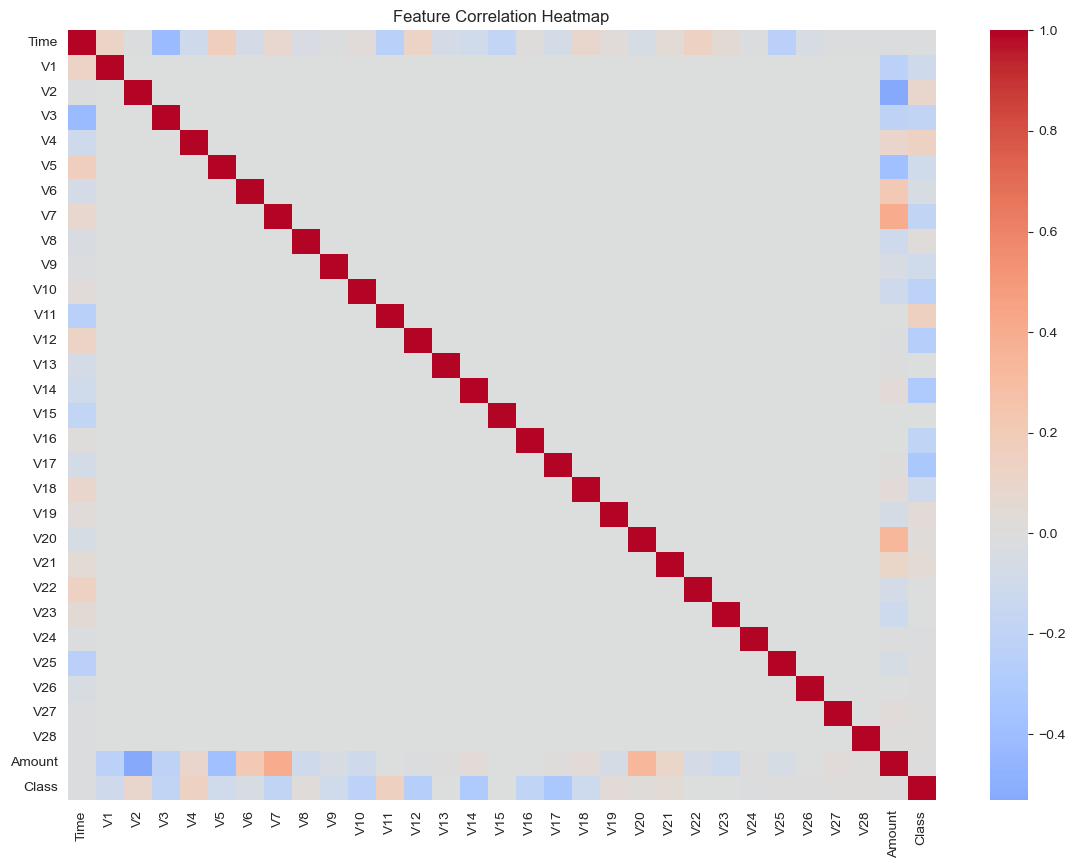

In [14]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

### Handling Class Imbalance — Random Undersampling

Since fraud cases are only 492 out of 284,807 records, an equal number of legitimate transactions (492) are randomly sampled to create a balanced dataset for training.

In [15]:
normal_sample = normal.sample(n=492, random_state=42)
new_df = pd.concat([normal_sample, fraud], axis=0)

print("New Balanced Dataset Shape:", new_df.shape)
new_df['Class'].value_counts()

New Balanced Dataset Shape: (984, 31)


Class
0    492
1    492
Name: count, dtype: int64

### Class Count (After Undersampling)

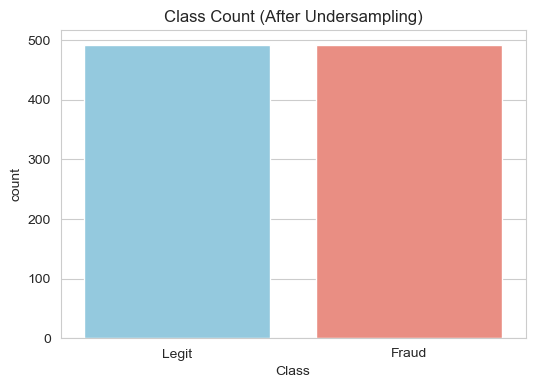

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=new_df, palette=['skyblue', 'salmon'])
plt.title('Class Count (After Undersampling)')
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.show()

In [17]:
new_df.groupby('Class').mean(numeric_only=True)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0,95052.758130,0.153312,0.009649,-0.038029,-0.027323,0.061966,-0.053962,0.013795,0.014911,0.037348,...,0.015030,0.014059,-0.020781,0.013223,-0.007257,0.024646,-0.027696,0.011070,-0.002305,80.348354
1,80746.806911,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.372319,0.713588,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321


### Splitting Features & Target

In [18]:
X = new_df.drop(columns='Class', axis=1)
y = new_df['Class']

## Feature Scaling

The `Amount` and `Time` columns are scaled using `StandardScaler`, since the remaining features (V1–V28) are already PCA-transformed and scaled.

In [19]:
scaler_amount = StandardScaler()
scaler_time = StandardScaler()

In [20]:
X['Amount'] = scaler_amount.fit_transform(X[['Amount']])
X['Time'] = scaler_time.fit_transform(X[['Time']])

In [21]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
138028,-0.113614,1.314539,0.590643,-0.666593,0.716564,0.301978,-1.125467,0.388881,-0.288390,-0.132137,...,-0.058040,-0.170307,-0.429655,-0.141341,-0.200195,0.639491,0.399476,-0.034321,0.031692,-0.453503
63099,-0.778566,-0.798672,1.185093,0.904547,0.694584,0.219041,-0.319295,0.495236,0.139269,-0.760214,...,-0.081298,0.202287,0.578699,-0.092245,0.013723,-0.246466,-0.380057,-0.396030,-0.112901,-0.438074
73411,-0.683272,-0.391128,-0.245540,1.122074,-1.308725,-0.639891,0.008678,-0.701304,-0.027315,-2.628854,...,0.065716,-0.133485,0.117403,-0.191748,-0.488642,-0.309774,0.008100,0.163716,0.239582,-0.389258
164247,0.597744,-0.060302,1.065093,-0.987421,-0.029567,0.176376,-1.348539,0.775644,0.134843,-0.149734,...,-0.169706,0.355576,0.907570,-0.018454,-0.126269,-0.339923,-0.150285,-0.023634,0.042330,-0.199772
148999,0.052832,1.848433,0.373364,0.269272,3.866438,0.088062,0.970447,-0.721945,0.235983,0.683491,...,-0.282777,0.103563,0.620954,0.197077,0.692392,-0.206530,-0.021328,-0.019823,-0.042682,-0.456932


### Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify = y)

In [23]:
print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X shape: (984, 30)
X_train shape: (787, 30)
X_test shape: (197, 30)


### Training Multiple Models

Four different classification models are trained and compared:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)

In [24]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

### Logistic Regression

In [25]:
log_model = LogisticRegression(random_state=42)

In [26]:
log_model.fit(X_train, y_train)

LogisticRegression(random_state=42)

### Decision Tree Classifier

In [27]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### Random Forest Classifier

In [28]:
rf_model = RandomForestClassifier(random_state=42)

In [29]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### KNeighbors Classifier

In [30]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [31]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [32]:
trained_models = {
    'Logistic Regression': log_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'KNN': knn_model
}

### Predictions for Each Model

In [33]:
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

In [34]:
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

In [35]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [36]:
knn_pred = knn_model.predict(X_test)
knn_prob = knn_model.predict_proba(X_test)[:, 1]

  File "C:\Users\nk026\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nk026\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nk026\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nk026\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [37]:
predictions = {
    'Logistic Regression': log_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'KNN': knn_pred
}

In [38]:
probabilities = {
    'Logistic Regression': log_prob,
    'Decision Tree': dt_prob,
    'Random Forest': rf_prob,
    'KNN': knn_prob
}

### Accuracy Comparison — Train vs Test

In [39]:
log_train_acc = accuracy_score(y_train, log_model.predict(X_train))
log_test_acc = accuracy_score(y_test, log_pred)

In [40]:
dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, dt_pred)

In [41]:
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, rf_pred)

In [42]:
knn_train_acc = accuracy_score(y_train, knn_model.predict(X_train))
knn_test_acc = accuracy_score(y_test, knn_pred)

In [43]:
results = [
    {'Model': 'Logistic Regression', 'Train Accuracy': log_train_acc, 'Test Accuracy': log_test_acc},
    {'Model': 'Decision Tree',       'Train Accuracy': dt_train_acc,  'Test Accuracy': dt_test_acc},
    {'Model': 'Random Forest',       'Train Accuracy': rf_train_acc,  'Test Accuracy': rf_test_acc},
    {'Model': 'KNN',                 'Train Accuracy': knn_train_acc, 'Test Accuracy': knn_test_acc},
]

In [44]:
results_df = pd.DataFrame(results)
results_df

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.960610,0.934010
1,Decision Tree,1.000000,0.893401
2,Random Forest,1.000000,0.934010
3,KNN,0.952986,0.923858


### Accuracy Comparison

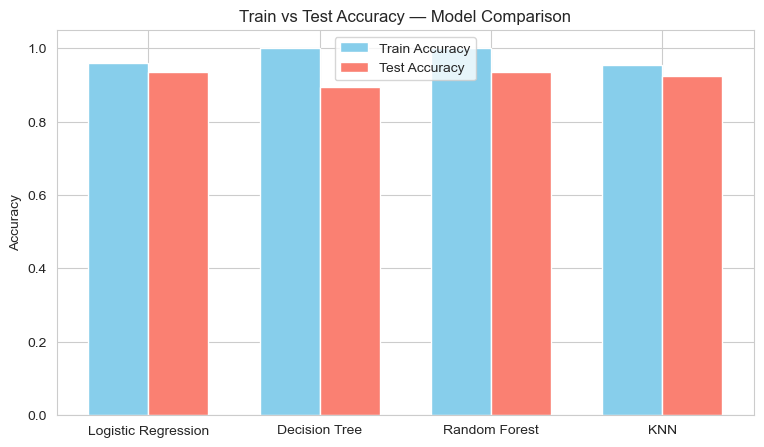

In [45]:
plt.figure(figsize=(9,5))

models_list = results_df['Model']
train_scores = results_df['Train Accuracy']
test_scores = results_df['Test Accuracy']

bar_width = 0.35
positions1 = range(len(models_list))
positions2 = [p + bar_width for p in positions1]

plt.bar(positions1, train_scores, width=bar_width, color='skyblue', label='Train Accuracy')
plt.bar(positions2, test_scores, width=bar_width, color='salmon', label='Test Accuracy')

plt.xticks([p + bar_width/2 for p in positions1], models_list)
plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy — Model Comparison')
plt.legend()
plt.show()

### Confusion Matrix — Each Model

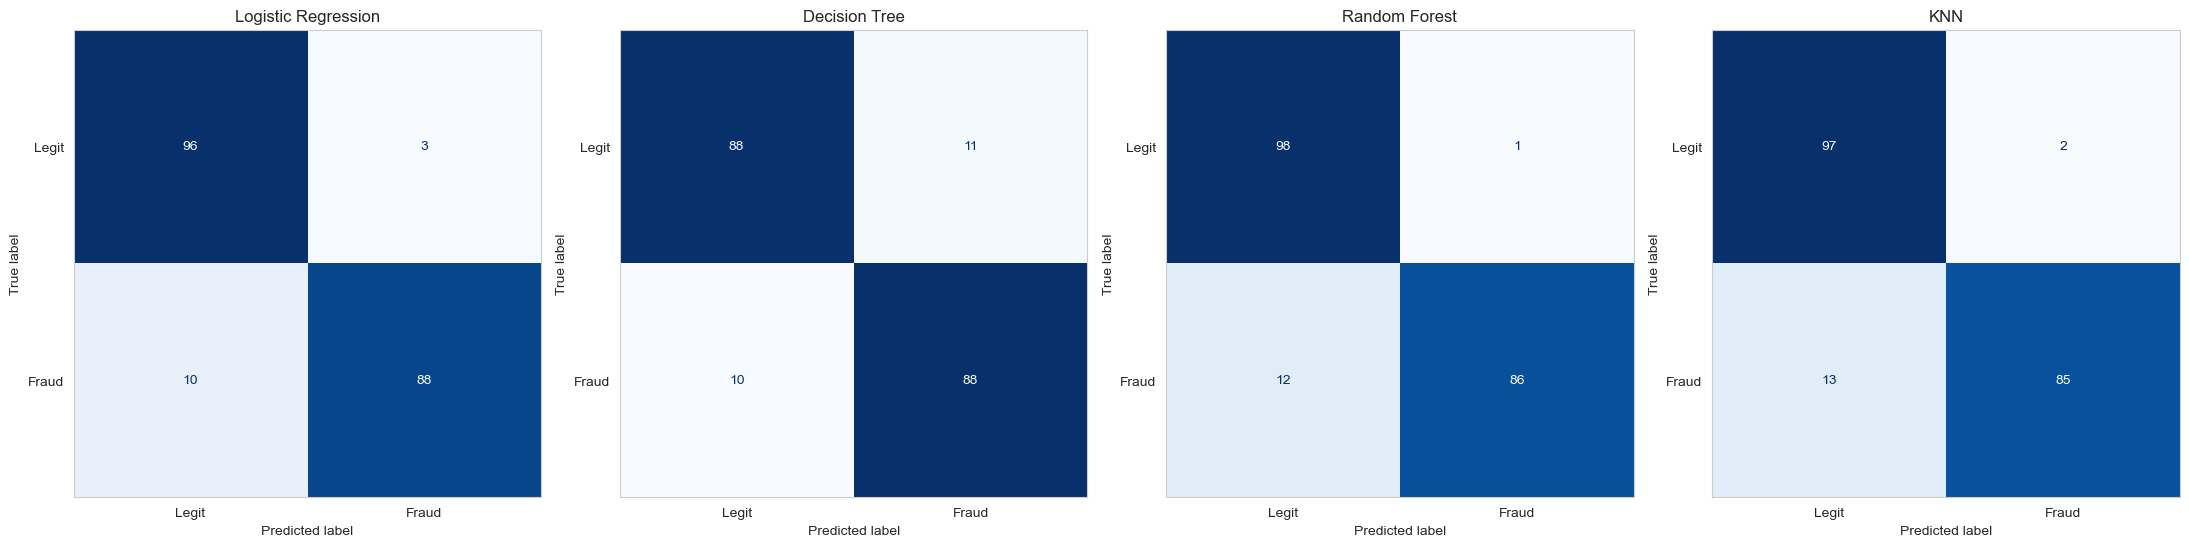

In [46]:
fig, axes = plt.subplots(1, 4, figsize=(22,6))

# Model 1 - Logistic Regression
cm1 = confusion_matrix(y_test, log_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Legit','Fraud'])
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')
axes[0].grid(False)

# Model 2 - Decision Tree
cm2 = confusion_matrix(y_test, dt_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Legit','Fraud'])
disp2.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Decision Tree')
axes[1].grid(False)

# Model 3 - Random Forest
cm3 = confusion_matrix(y_test, rf_pred)
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=['Legit','Fraud'])
disp3.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Random Forest')
axes[2].grid(False)

# Model 4 - KNN
cm4 = confusion_matrix(y_test, knn_pred)
disp4 = ConfusionMatrixDisplay(confusion_matrix=cm4, display_labels=['Legit','Fraud'])
disp4.plot(ax=axes[3], cmap='Blues', colorbar=False)
axes[3].set_title('KNN')
axes[3].grid(False)

plt.tight_layout()
plt.show()

### Classification Report — Each Model

In [47]:
# Classification report - har model ke liye alag se

print(f"==================== Logistic Regression ===========================")
print(classification_report(y_test, log_pred, target_names=['Legit', 'Fraud']))
print()

print(f"===================== Decision Tree ================================")
print(classification_report(y_test, dt_pred, target_names=['Legit', 'Fraud']))
print()

print(f"===================== Random Forest ================================")
print(classification_report(y_test, rf_pred, target_names=['Legit', 'Fraud']))
print()

print(f"===================== KNN ===========================================")
print(classification_report(y_test, knn_pred, target_names=['Legit', 'Fraud']))
print()

==================== Logistic Regression ===========================
              precision    recall  f1-score   support

       Legit       0.91      0.97      0.94        99
       Fraud       0.97      0.90      0.93        98

    accuracy                           0.93       197
   macro avg       0.94      0.93      0.93       197
weighted avg       0.94      0.93      0.93       197


===================== Decision Tree ================================
              precision    recall  f1-score   support

       Legit       0.90      0.89      0.89        99
       Fraud       0.89      0.90      0.89        98

    accuracy                           0.89       197
   macro avg       0.89      0.89      0.89       197
weighted avg       0.89      0.89      0.89       197


===================== Random Forest ================================
              precision    recall  f1-score   support

       Legit       0.89      0.99      0.94        99
       Fraud       0.99     

### ROC Curve Comparison (All Models)

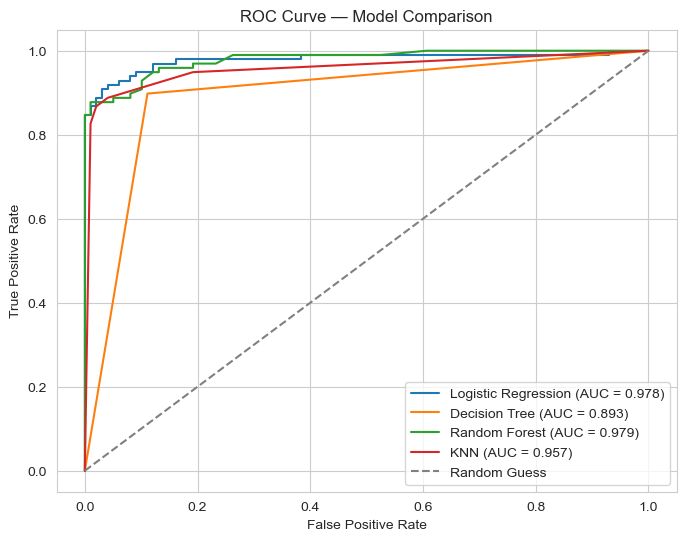

In [48]:
plt.figure(figsize=(8,6))

# Logistic Regression
fpr1, tpr1, _ = roc_curve(y_test, log_prob)
auc1 = roc_auc_score(y_test, log_prob)
plt.plot(fpr1, tpr1, label=f'Logistic Regression (AUC = {auc1:.3f})')

# Decision Tree
fpr2, tpr2, _ = roc_curve(y_test, dt_prob)
auc2 = roc_auc_score(y_test, dt_prob)
plt.plot(fpr2, tpr2, label=f'Decision Tree (AUC = {auc2:.3f})')

# Random Forest
fpr3, tpr3, _ = roc_curve(y_test, rf_prob)
auc3 = roc_auc_score(y_test, rf_prob)
plt.plot(fpr3, tpr3, label=f'Random Forest (AUC = {auc3:.3f})')

# KNN
fpr4, tpr4, _ = roc_curve(y_test, knn_prob)
auc4 = roc_auc_score(y_test, knn_prob)
plt.plot(fpr4, tpr4, label=f'KNN (AUC = {auc4:.3f})')

# Baseline - random guess wali line
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.show()

### Precision-Recall Curve Comparison (All Models)

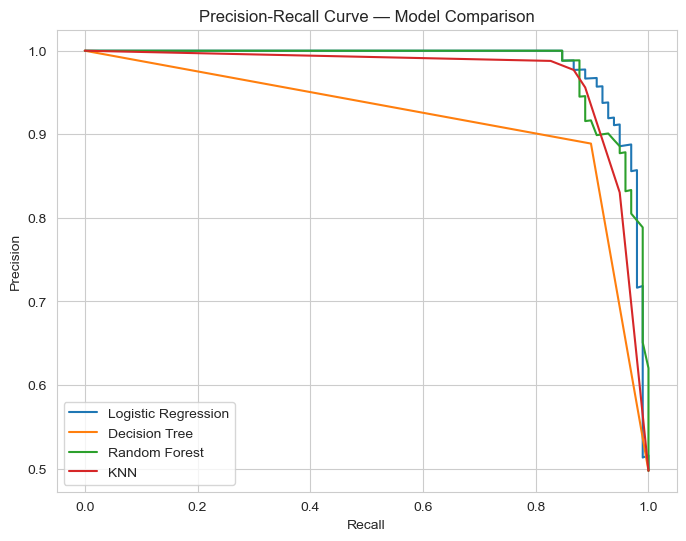

In [49]:
plt.figure(figsize=(8,6))

# Logistic Regression
precision1, recall1, _ = precision_recall_curve(y_test, log_prob)
plt.plot(recall1, precision1, label='Logistic Regression')

# Decision Tree
precision2, recall2, _ = precision_recall_curve(y_test, dt_prob)
plt.plot(recall2, precision2, label='Decision Tree')

# Random Forest
precision3, recall3, _ = precision_recall_curve(y_test, rf_prob)
plt.plot(recall3, precision3, label='Random Forest')

# KNN
precision4, recall4, _ = precision_recall_curve(y_test, knn_prob)
plt.plot(recall4, precision4, label='KNN')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Model Comparison')
plt.legend()
plt.show()

### Which Model Performs Best?

| Model | Train Accuracy | Test Accuracy | ROC-AUC | Fraud Recall | Overfitting Gap |
|---|---|---|---|---|---|
| **Logistic Regression** | 96.06% | 93.40% | **0.978** | 89.8% | Low (2.6%) |
| Decision Tree | 100% | 89.34% | 0.893 | 89.8% | High (10.7%) |
| Random Forest | 100% | 93.40% | **0.979** | 87.8% | Moderate (6.6%) |
| KNN | 95.30% | 92.39% | 0.957 | 86.7% | Low (2.9%) |

**Best Model: Logistic Regression**

Random Forest and Logistic Regression achieve almost identical ROC-AUC scores (0.979 vs 0.978),
but Logistic Regression is preferred because it:

- Catches more fraud cases (higher recall)
- Shows the smallest gap between train and test accuracy, meaning it generalizes better
- Is simpler, faster, and easier to interpret and deploy

Random Forest is a close second and would likely outperform Logistic Regression if its
hyperparameters (`max_depth`, `min_samples_leaf`) are tuned to reduce overfitting.

---

### Feature Importance (Logistic Regression)

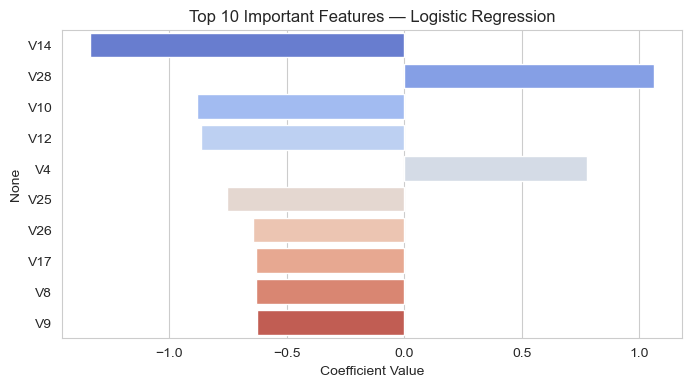

In [50]:
importance_lr = pd.Series(log_model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=importance_lr.values[:10], y=importance_lr.index[:10], palette='coolwarm')
plt.title('Top 10 Important Features — Logistic Regression')
plt.xlabel('Coefficient Value')
plt.show()

## Real-World Evaluation (Full Imbalanced Dataset)

**Important:** All metrics above (93.4% accuracy, 0.978 AUC) were computed on a *balanced*
test set created via undersampling (492 fraud vs 492 legit). This does **not** reflect
real-world performance, where fraud is only ~0.17% of transactions.

Below, we evaluate the same trained `log_model` on the **full original imbalanced dataset**,
excluding every row that was part of the balanced training/undersampled set (`new_df`) to
avoid data leakage. This gives a true picture of production-level performance.

In [51]:
from sklearn.metrics import average_precision_score

# Rebuild full feature set using the SAME scalers fit during training
X_full = df.drop(columns='Class').copy()
y_full = df['Class'].copy()
X_full['Amount'] = scaler_amount.transform(X_full[['Amount']])
X_full['Time'] = scaler_time.transform(X_full[['Time']])
X_full = X_full[X.columns]  # match training column order

In [52]:
# Exclude ONLY rows used to actually FIT the model (X_train) -> avoids leakage,
# but keeps X_test's fraud rows + all untouched normal rows -> both classes present
mask = ~X_full.index.isin(X_train.index)
X_holdout = X_full[mask]
y_holdout = y_full[mask]

print("Holdout set size:", X_holdout.shape[0])
print(f"Fraud cases in holdout: {y_holdout.sum()} ({y_holdout.mean()*100:.4f}% of holdout)\n")

Holdout set size: 284020
Fraud cases in holdout: 98 (0.0345% of holdout)



In [53]:
y_holdout_pred = log_model.predict(X_holdout)
y_holdout_prob = log_model.predict_proba(X_holdout)[:, 1]

print("--- Classification Report on REAL imbalanced distribution ---")
print(classification_report(y_holdout, y_holdout_pred, digits=4))

print("ROC-AUC:", round(roc_auc_score(y_holdout, y_holdout_prob), 4))
print("PR-AUC (Average Precision):", round(average_precision_score(y_holdout, y_holdout_prob), 4))

--- Classification Report on REAL imbalanced distribution ---
              precision    recall  f1-score   support

           0     1.0000    0.9680    0.9837    283922
           1     0.0096    0.8980    0.0190        98

    accuracy                         0.9680    284020
   macro avg     0.5048    0.9330    0.5014    284020
weighted avg     0.9996    0.9680    0.9834    284020

ROC-AUC: 0.9766
PR-AUC (Average Precision): 0.3544


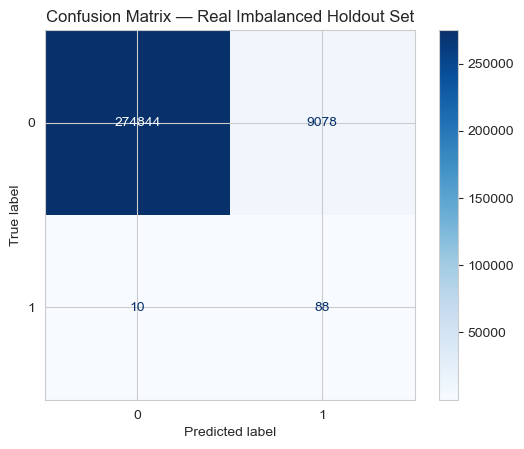

In [54]:
cm = confusion_matrix(y_holdout, y_holdout_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Confusion Matrix — Real Imbalanced Holdout Set')
plt.show()

In [55]:
import joblib

# Best model (Logistic Regression)
joblib.dump(log_model, 'fraud_detection_model.pkl')

joblib.dump(scaler_amount, 'scaler_amount.pkl')

joblib.dump(scaler_time, 'scaler_time.pkl')

joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Model, scaler aur feature columns saved successfully!")

Model, scaler aur feature columns saved successfully!


## Conclusion

This project demonstrates a complete pipeline for detecting fraudulent credit card transactions
on a highly imbalanced dataset.

**Key Takeaways:**

- Undersampling successfully balanced the dataset (492 fraud vs 492 legit samples), enabling
  fair model training.
- **Logistic Regression** emerged as the most reliable model, achieving **93.4% test accuracy**
  and a **0.978 ROC-AUC score**, with the lowest overfitting among all models tested.
- **Random Forest** performed comparably well (0.979 AUC) but showed signs of overfitting on
  training data.
- **Decision Tree** and **KNN** were less consistent, with Decision Tree overfitting the most.
- Evaluation went beyond accuracy alone, using Confusion Matrices, Precision-Recall curves, and
  ROC-AUC — essential for imbalanced classification problems like fraud detection.
- **Real-world check:** On the full imbalanced holdout set, the model gets **89.8% recall**
  but only **0.96% precision** — it catches most fraud but with many false alarms, a known
  trade-off of undersampling that threshold tuning or SMOTE could improve further.